# Notebook 02: Veri Görselleştirme
Bu notebook'un amacı, birinci aşamada temizlenen veriler üzerinden tüketim dağılımlarını, mevsimsel trendleri ve tahsilat performanslarını (zamanında vs. geç ödeme oranları) Matplotlib ve Seaborn kütüphaneleri kullanılarak görselleştirmektir.

In [8]:
from google.colab import files
uploaded = files.upload()


Saving elektrik_veri_hashed.xlsx to elektrik_veri_hashed (1).xlsx


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

dosya_adi = 'elektrik_veri_hashed (1).xlsx'

df_tahsilat = pd.read_excel(dosya_adi, sheet_name='Tahsilat')
df_tahsilat_1 = pd.read_excel(dosya_adi, sheet_name='Tahsilat 1')
df_tahakkuk = pd.read_excel(dosya_adi, sheet_name='Tahakkuk')
df_tahakkuk_1 = pd.read_excel(dosya_adi, sheet_name='Tahakkuk 1')
df_tahakkuk_2 = pd.read_excel(dosya_adi, sheet_name='Tahakkuk 2')

# Grafikler için verileri hazırlama
df_tahakkuk['ilce'] = 'Hamamözü'
df_tahakkuk_1['ilce'] = 'Gümüşhacıköy'
df_tahakkuk_2['ilce'] = 'Göynücek'

tum_tahakkuk = pd.concat([df_tahakkuk, df_tahakkuk_1, df_tahakkuk_2], ignore_index=True)

print("Görselleştirme için sayfalar okundu ve veri birleştirildi!")

Görselleştirme için sayfalar okundu ve veri birleştirildi!


/tmp/ipykernel_2618/476248075.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=ilce_verisi, x='hesap_sinifi', ax=axes[i], palette='viridis')
/tmp/ipykernel_2618/476248075.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=ilce_verisi, x='hesap_sinifi', ax=axes[i], palette='viridis')
/tmp/ipykernel_2618/476248075.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=ilce_verisi, x='hesap_sinifi', ax=axes[i], palette='viridis')


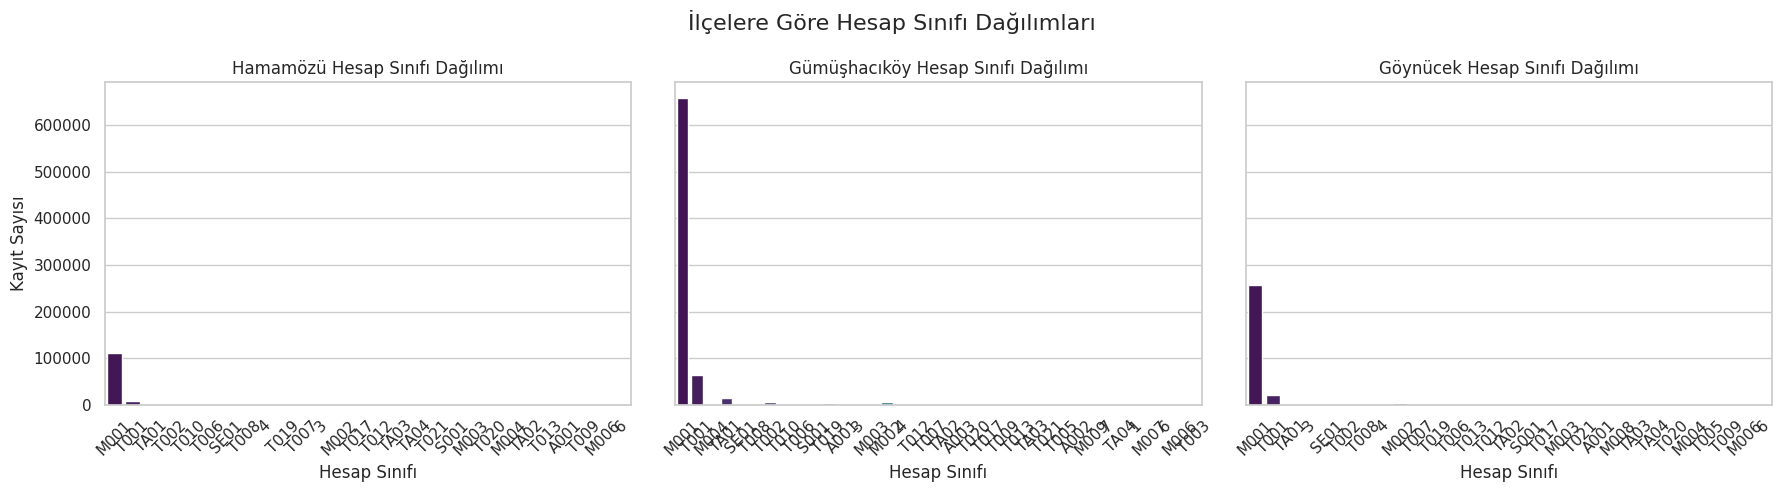

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle('İlçelere Göre Hesap Sınıfı Dağılımları', fontsize=16)

ilceler = ['Hamamözü', 'Gümüşhacıköy', 'Göynücek']

for i, ilce in enumerate(ilceler):

    ilce_verisi = tum_tahakkuk[tum_tahakkuk['ilce'] == ilce]

    sns.countplot(data=ilce_verisi, x='hesap_sinifi', ax=axes[i], palette='viridis')

    axes[i].set_title(f'{ilce} Hesap Sınıfı Dağılımı')
    axes[i].set_xlabel('Hesap Sınıfı')
    axes[i].set_ylabel('Kayıt Sayısı' if i == 0 else '')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

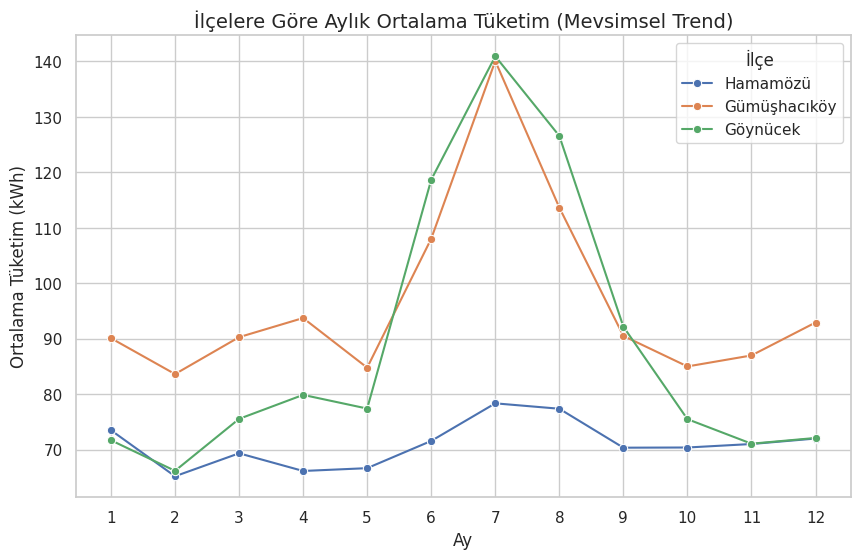

In [18]:
tum_tahakkuk['mali_yil_donem'] = pd.to_datetime(tum_tahakkuk['mali_yil_donem'])
tum_tahakkuk['ay'] = tum_tahakkuk['mali_yil_donem'].dt.month

plt.figure(figsize=(10, 6))

sns.lineplot(data=tum_tahakkuk, x='ay', y='kwh', hue='ilce', marker='o', errorbar=None)

plt.title('İlçelere Göre Aylık Ortalama Tüketim (Mevsimsel Trend)', fontsize=14)
plt.xlabel('Ay')
plt.ylabel('Ortalama Tüketim (kWh)')
plt.xticks(range(1, 13))
plt.legend(title='İlçe')
plt.show()

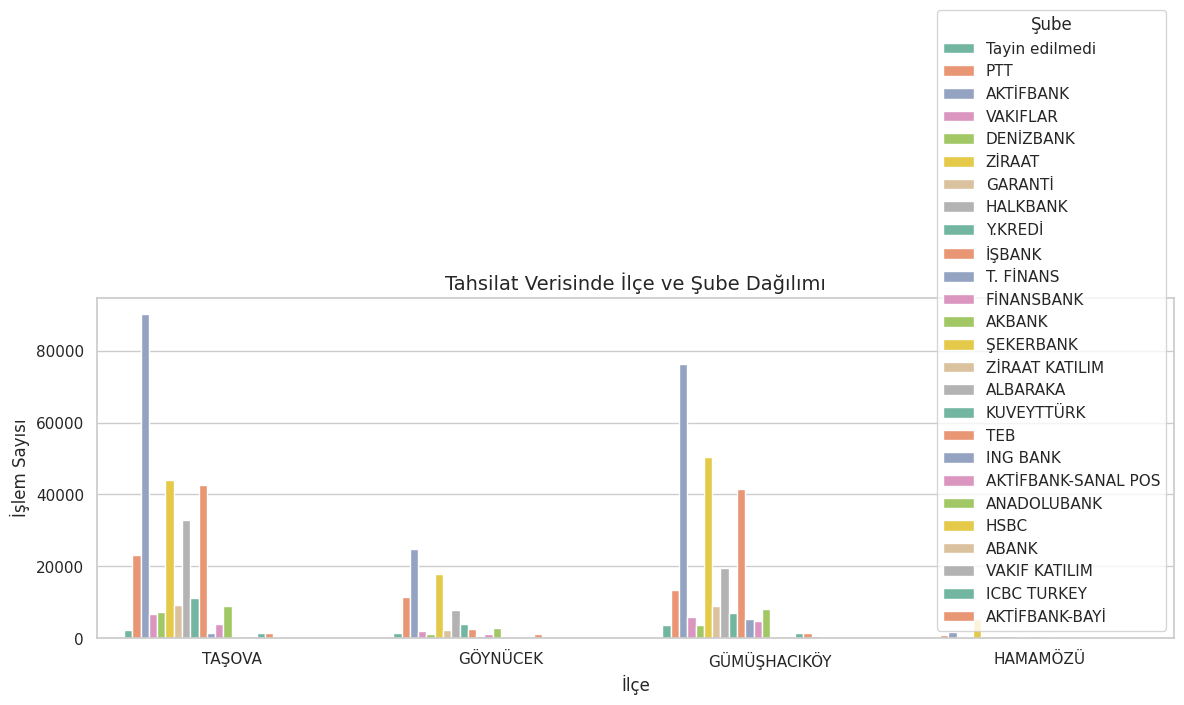

In [19]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df_tahsilat, x='İlçe', hue='Şube', palette='Set2')

plt.title('Tahsilat Verisinde İlçe ve Şube Dağılımı', fontsize=14)
plt.xlabel('İlçe')
plt.ylabel('İşlem Sayısı')
plt.legend(title='Şube')
plt.tight_layout()
plt.show()

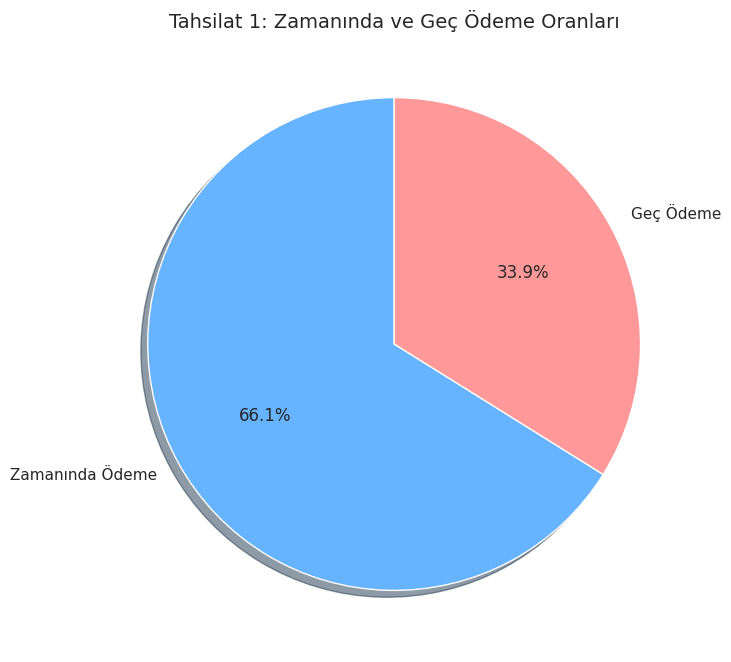

In [20]:
import matplotlib.pyplot as plt

zamaninda_sutunlar = [
    'Son Ödeme Tarihinden Önceki Tahsilat',
    'Son Ödeme Tarihindeki Tahsilat'
]
zamaninda_toplam = df_tahsilat_1[zamaninda_sutunlar].sum().sum()

gec_sutunlar = [
    'Son Ödeme (1)', 'Son Ödeme (2)', 'Son Ödeme (3)', 'Son Ödeme (4)',
    'Son Ödeme (5)', 'Son Ödeme (6-10)', 'Son Ödeme (10-20)', 'Son Ödeme (20-30)',
    'Son Ödeme (30-60)', 'Son Ödeme (60-90)', 'Son Ödeme (90-120)',
    'Son Ödeme (120-150)', 'Son Ödeme (150-180)', 'Son Ödeme (180+)'
]
gec_toplam = df_tahsilat_1[gec_sutunlar].sum().sum()

durumlar = ['Zamanında Ödeme', 'Geç Ödeme']
degerler = [zamaninda_toplam, gec_toplam]

plt.figure(figsize=(8, 8))
plt.pie(degerler, labels=durumlar, autopct='%1.1f%%',
        startangle=90, colors=['#66b3ff', '#ff9999'], shadow=True)

plt.title('Tahsilat 1: Zamanında ve Geç Ödeme Oranları', fontsize=14)
plt.show()

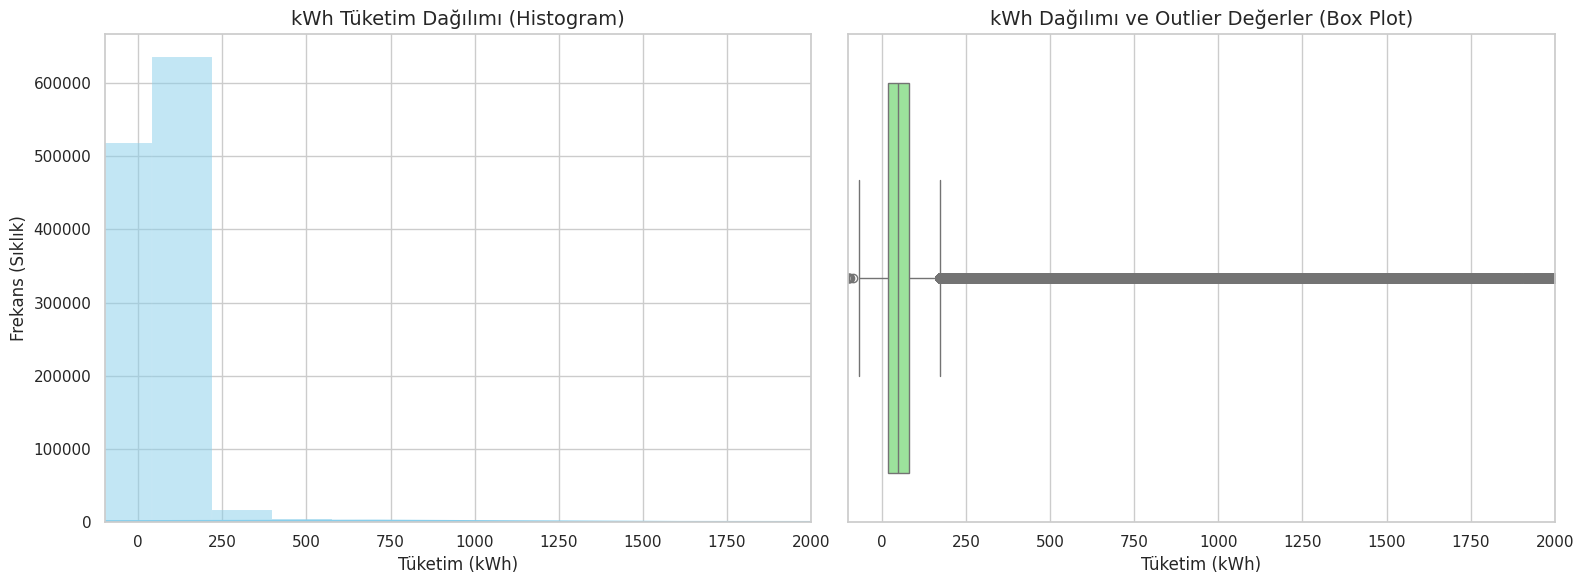

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(tum_tahakkuk['kwh'], bins=1000, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('kWh Tüketim Dağılımı (Histogram)', fontsize=14)
axes[0].set_xlabel('Tüketim (kWh)')
axes[0].set_ylabel('Frekans (Sıklık)')
axes[0].set_xlim(-100, 2000)

sns.boxplot(x=tum_tahakkuk['kwh'], ax=axes[1], color='lightgreen')
axes[1].set_title('kWh Dağılımı ve Outlier Değerler (Box Plot)', fontsize=14)
axes[1].set_xlabel('Tüketim (kWh)')
axes[1].set_xlim(-100, 2000)

plt.tight_layout()
plt.show()